####ANALISE EXPLORATÓRIA DE DADOS

### 1. Importação de Bibliotecas e Carregamento dos Dados
Nesta etapa, preparamos o ambiente e visualizamos as primeiras linhas do dataset.

In [4]:
# Carregando o dataset selecionado
url = 'https://raw.githubusercontent.com/itgirlhightech/Ada-Churn-Project/refs/heads/main/src/Churn_Modelling_original.csv?token=GHSAT0AAAAAAD4KGRF3LUNVTBEV7Q6E3NW62P57QMA'
df = pd.read_csv(url)
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os
import pandas as pd



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 2. Limpeza Inicial
Vamos verificar se existem valores nulos (NaN) ou duplicados que possam enviesar o modelo.

In [9]:
# Verificando valores ausentes
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Verificando duplicados
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Linhas duplicadas: 0


### 3. Análise Estatística e Distribuição do Target
Vamos observar as medidas centrais e a proporção de Churn (Exited).

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


/tmp/ipykernel_575/405310304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


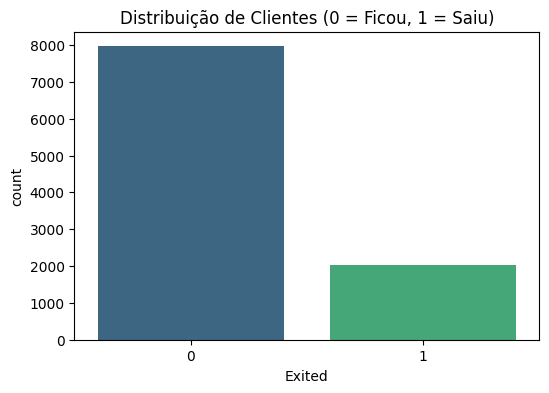

Proporção de Churn:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [10]:
# Resumo estatístico das variáveis numéricas
display(df.describe())

# Verificando o balanceamento da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribuição de Clientes (0 = Ficou, 1 = Saiu)')
plt.show()

print("Proporção de Churn:")
print(df['Exited'].value_counts(normalize=True) * 100)

### 4. Análise de Variáveis Categóricas e Correlação
Vamos investigar como variáveis como país e gênero impactam a decisão de sair do banco, além de analisar a correlação entre as variáveis numéricas.

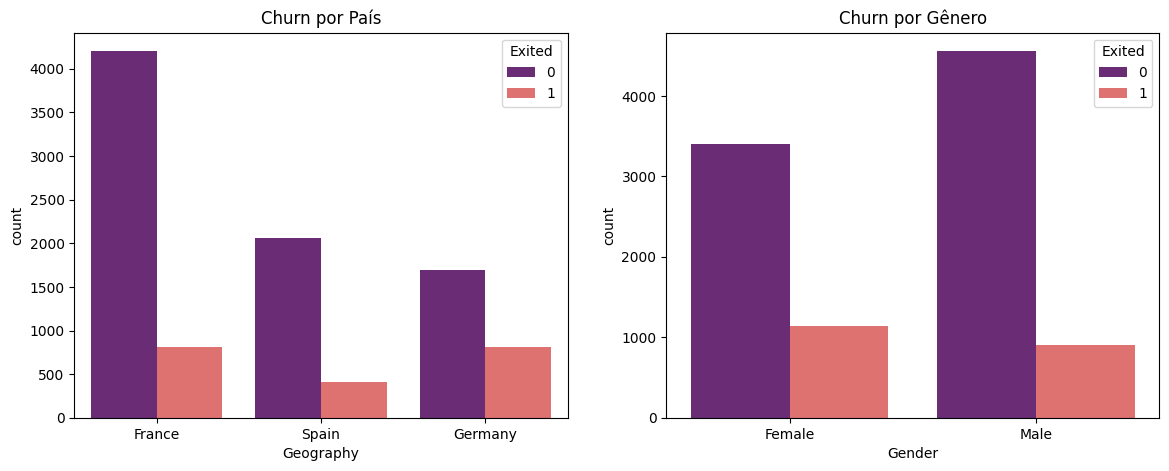

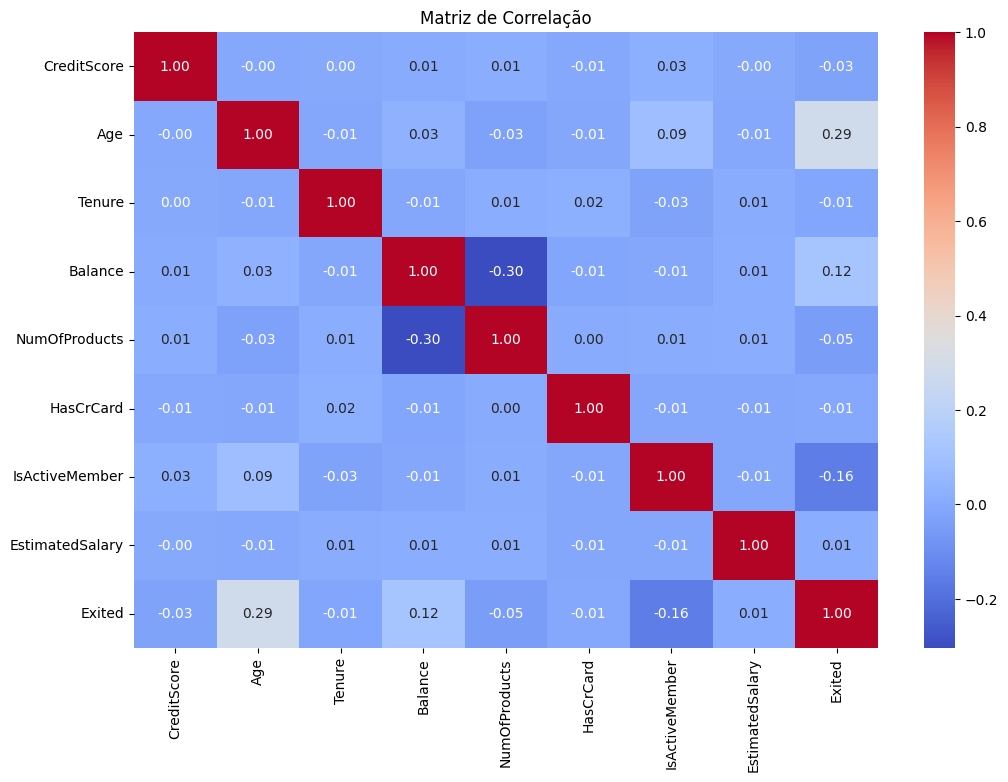

In [11]:
# Comparação de Churn por Geografia e Gênero
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Geography', hue='Exited', data=df, ax=ax[0], palette='magma')
ax[0].set_title('Churn por País')

sns.countplot(x='Gender', hue='Exited', data=df, ax=ax[1], palette='magma')
ax[1].set_title('Churn por Gênero')

plt.show()

# Mapa de Calor de Correlação
plt.figure(figsize=(12, 8))
# Selecionando apenas colunas numéricas para o heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['RowNumber', 'CustomerId'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

### 3. Análise Estatística e Distribuição do Target
Vamos observar as medidas centrais e a proporção de Churn (Exited).

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


/tmp/ipykernel_575/405310304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


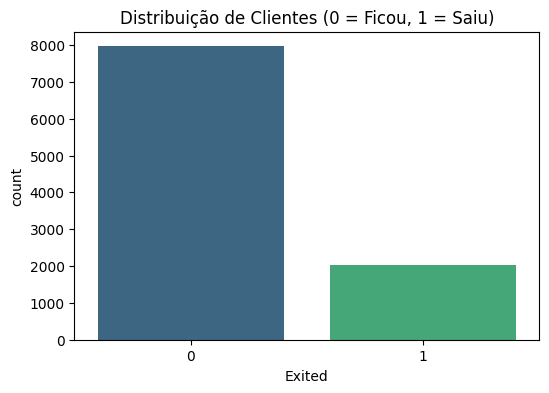

Proporção de Churn:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [12]:
# Resumo estatístico das variáveis numéricas
display(df.describe())

# Verificando o balanceamento da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribuição de Clientes (0 = Ficou, 1 = Saiu)')
plt.show()

print("Proporção de Churn:")
print(df['Exited'].value_counts(normalize=True) * 100)

## 3.1 Análise de Faixa Etária

#### Relação entre churn (Exited) e faixa etária dos clientes

,Age,FaixaEtaria
0,42,Adulto
1,41,Adulto
2,42,Adulto
3,39,Adulto
4,43,Adulto


Distribuição de Churn (Exited) por Faixa Etária e Gênero


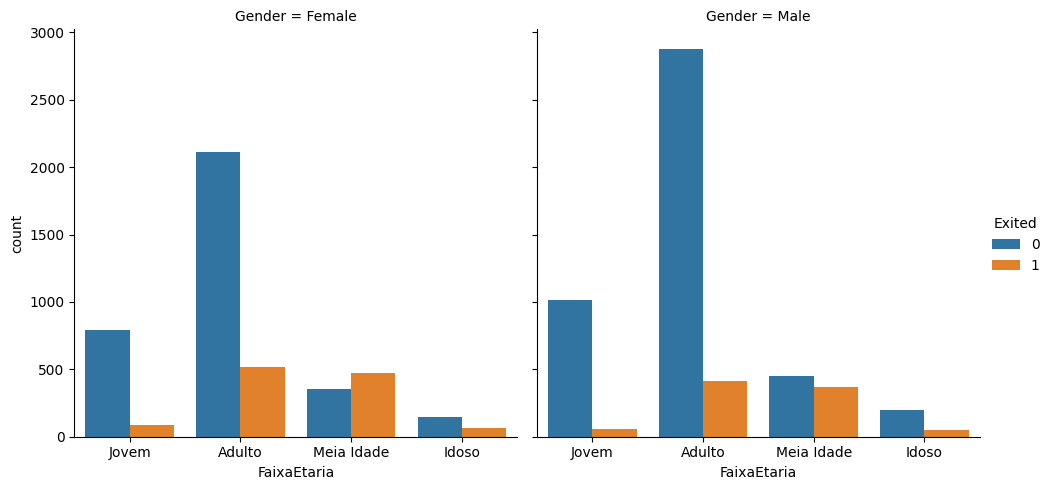

In [13]:
bins = [18, 30, 45, 60, 100]
labels = ['Jovem', 'Adulto', 'Meia Idade', 'Idoso']



df['FaixaEtaria'] = pd.cut(
    df['Age'], bins=bins, labels=labels
     )

display(df[['Age', 'FaixaEtaria']].head())

sns.catplot(
    x='FaixaEtaria',
    hue='Exited',
    col='Gender',
    data=df,
    kind='count'
)

print('Distribuição de Churn (Exited) por Faixa Etária e Gênero')

plt.show()


##4. Análise por Score de Crédito


/tmp/ipykernel_575/1033024257.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=df, palette='viridis')


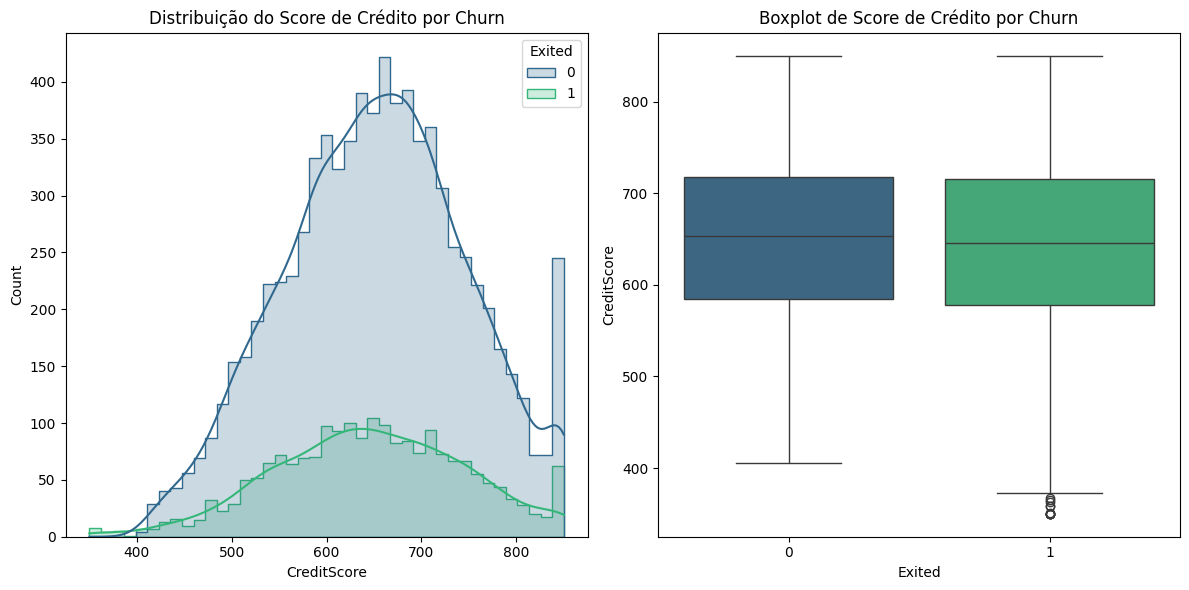

Estatísticas de Credit Score para quem saiu (Exited=1):


,CreditScore
count,2037.000000
mean,645.351497
std,100.321503
min,350.000000
25%,578.000000
50%,646.000000
75%,716.000000
max,850.000000



Estatísticas de Credit Score para quem ficou (Exited=0):


,CreditScore
count,7963.000000
mean,651.853196
std,95.653837
min,405.000000
25%,585.000000
50%,653.000000
75%,718.000000
max,850.000000


In [14]:
# Criando a figura para visualização
plt.figure(figsize=(12, 6))

# Subplot 1 (Gráfico 1): Distribuição de CreditScore por Churn
plt.subplot(1, 2, 1) #Organiza espaços da imagem onde virão os gráficos
sns.histplot(data=df, x='CreditScore', hue='Exited', kde=True, palette='viridis', element='step')
plt.title('Distribuição do Score de Crédito por Churn')

# Subplot 2 (Gráfico 2): Boxplot para verificar medianas e outliers
plt.subplot(1,2,2)
sns.boxplot(x='Exited', y='CreditScore', data=df, palette='viridis')
plt.title('Boxplot de Score de Crédito por Churn')

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print('Estatísticas de Credit Score para quem saiu (Exited=1):')
display(df[df['Exited'] == 1]['CreditScore'].describe())

print('\nEstatísticas de Credit Score para quem ficou (Exited=0):')
display(df[df['Exited'] == 0]['CreditScore'].describe())

In [ ]:
df.head()

##4.1 Análise por Score e Faixa Etária

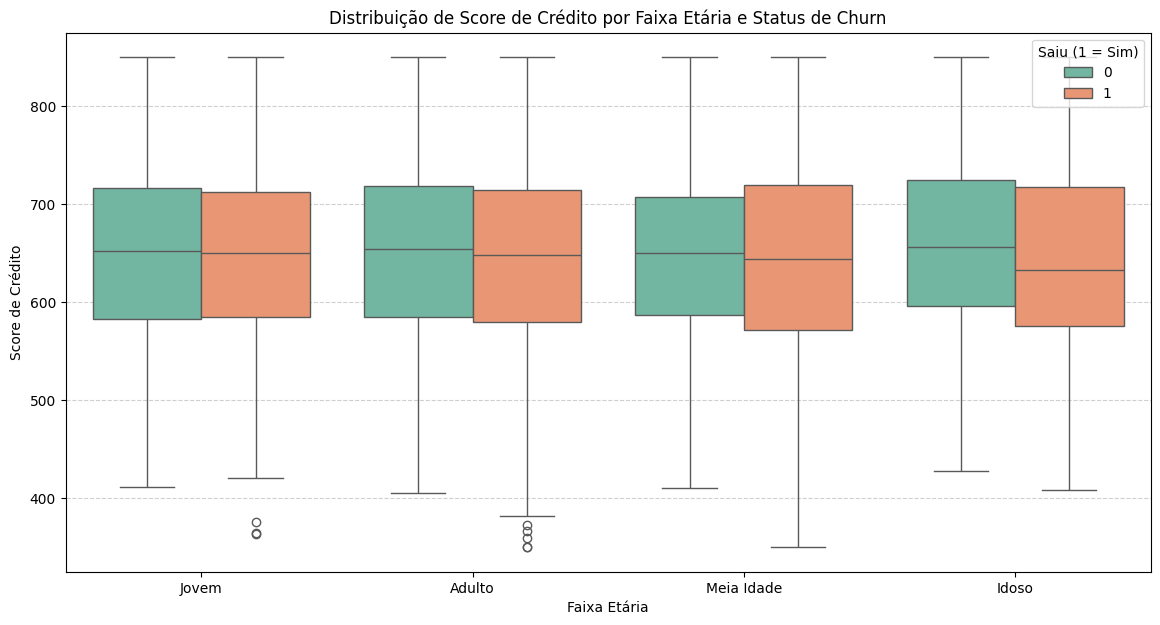

Média de Score de Crédito por Faixa Etária e Churn:


/tmp/ipykernel_575/3028306862.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_agrupada = df.groupby(['FaixaEtaria', 'Exited'])['CreditScore'].mean().unstack()


Exited,0,1
FaixaEtaria,,
Jovem,651.153889,646.431507
Adulto,652.006013,646.270386
Meia Idade,648.913043,644.248219
Idoso,657.902579,644.373913


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando um Boxplot que relaciona Faixa Etária, CreditScore e Churn
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='FaixaEtaria', y='CreditScore', hue='Exited', palette='Set2')

plt.title('Distribuição de Score de Crédito por Faixa Etária e Status de Churn')
plt.xlabel('Faixa Etária')
plt.ylabel('Score de Crédito')
plt.legend(title='Saiu (1 = Sim)', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Calculando a média de Score por Faixa Etária e Churn para análise numérica
print("Média de Score de Crédito por Faixa Etária e Churn:")
analise_agrupada = df.groupby(['FaixaEtaria', 'Exited'])['CreditScore'].mean().unstack()
display(analise_agrupada)

### 4.2 Ranking com base no Score

NivelRisco
Baixo Risco    6240
Médio Risco    2984
Alto Risco      776
Name: count, dtype: int64
NivelRisco
Alto Risco     66.494845
Baixo Risco    10.945513
Médio Risco    28.083110
Name: Exited, dtype: float64


/tmp/ipykernel_575/2324145670.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


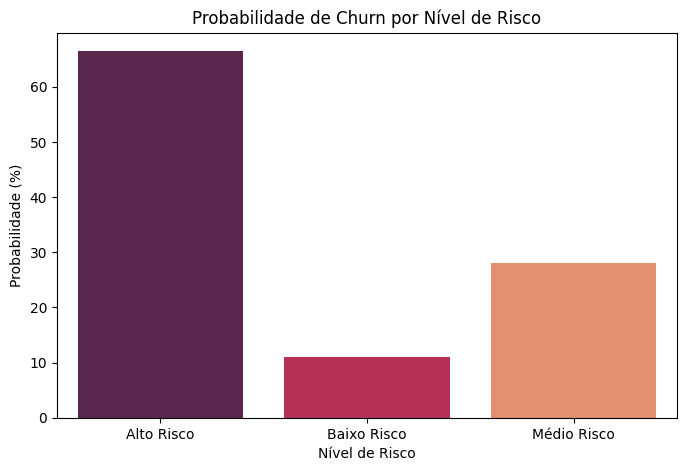

In [16]:
df['RiskScore'] = (
    (df['IsActiveMember'] ==0).astype(int)+
    (df['NumOfProducts'] ==1).astype(int) +
    (df['CreditScore'] < 500).astype(int) +
    (df['Age'] > 45).astype(int)
)

conditions = [
    (df['RiskScore'] <= 1),
    (df['RiskScore'] == 2),
    (df['RiskScore'] >= 3)
]

choices = [
    'Baixo Risco',
    'Médio Risco',
    'Alto Risco'
]

df['NivelRisco'] = np.select(
    conditions,
    choices,
    default='Não Classificado'
)


print(df['NivelRisco'].value_counts())

prob_risco = (
    df.groupby('NivelRisco')['Exited']
    .mean() * 100
)

print(prob_risco)

plt.figure(figsize=(8,5))

sns.barplot(
    x=prob_risco.index,
    y=prob_risco.values,
    palette='rocket'
)

plt.title('Probabilidade de Churn por Nível de Risco')

plt.xlabel('Nível de Risco')

plt.ylabel('Probabilidade (%)')

plt.show()

##5. Análise por Qtd de Produtos


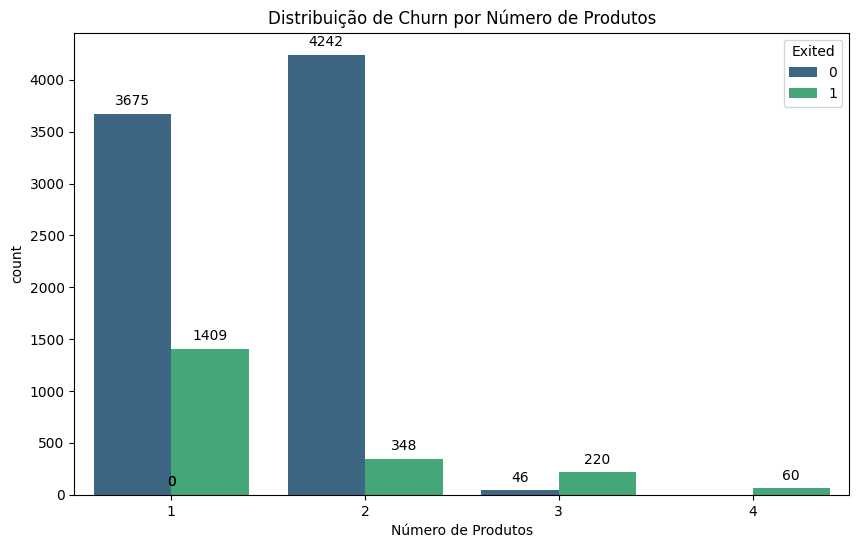

Taxa de Churn (%) por Número de Produtos:
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [17]:
# Visualização da relação entre Número de Produtos e Churn com totais
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='NumOfProducts', hue='Exited', palette='viridis')
plt.title('Distribuição de Churn por Número de Produtos')
plt.xlabel('Número de Produtos')

# Adicionando os números totais em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

# Cálculo da taxa de churn por quantidade de produtos
churn_rate_products = df.groupby('NumOfProducts')['Exited'].mean() * 100
print("Taxa de Churn (%) por Número de Produtos:")
print(churn_rate_products)

In [ ]:
df.info()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

## Análise por Clientes Ativos


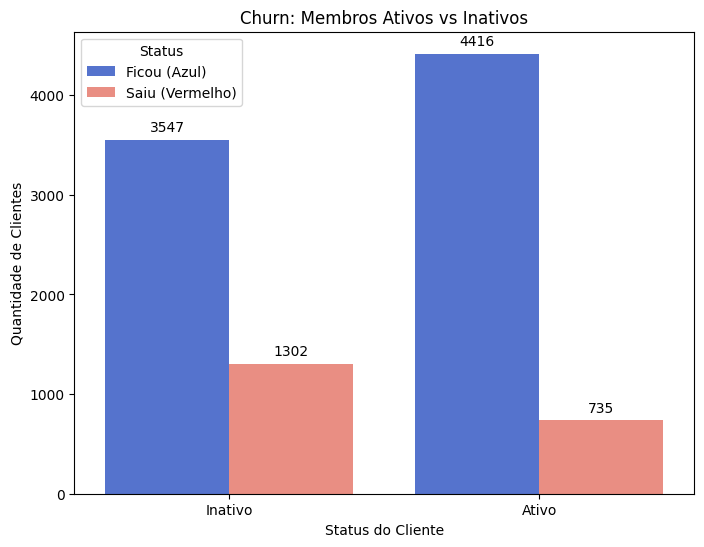

Taxa de Churn (%) por Status de Atividade:
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [18]:


# Criando a visualização de Churn por Membro Ativo
plt.figure(figsize=(8, 6))

# Definindo um mapeamento de cores explícito para evitar confusão
# 0 (Ficou) = Blue, 1 (Saiu) = Red
cores_mapeadas = {0: 'royalblue', 1: 'salmon'}

ax = sns.countplot(data=df, x='IsActiveMember', hue='Exited', palette=cores_mapeadas)

plt.title('Churn: Membros Ativos vs Inativos')
plt.xlabel('Status do Cliente')
plt.ylabel('Quantidade de Clientes')

# Ajustando as legendas do Eixo X
ax.set_xticks([0, 1])
ax.set_xticklabels(['Inativo', 'Ativo'])

# Adicionando rótulos de dados em cima das barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

# Melhorando a legenda para que combine com as cores forçadas
plt.legend(title='Status', labels=['Ficou (Azul)', 'Saiu (Vermelho)'])
plt.show()

# Cálculo da taxa de churn por status de atividade
churn_active = df.groupby('IsActiveMember')['Exited'].mean() * 100
print("Taxa de Churn (%) por Status de Atividade:")
print(churn_active)

In [ ]:
## Análise por Clientes com Cartão de Crédito e Score de Crédito

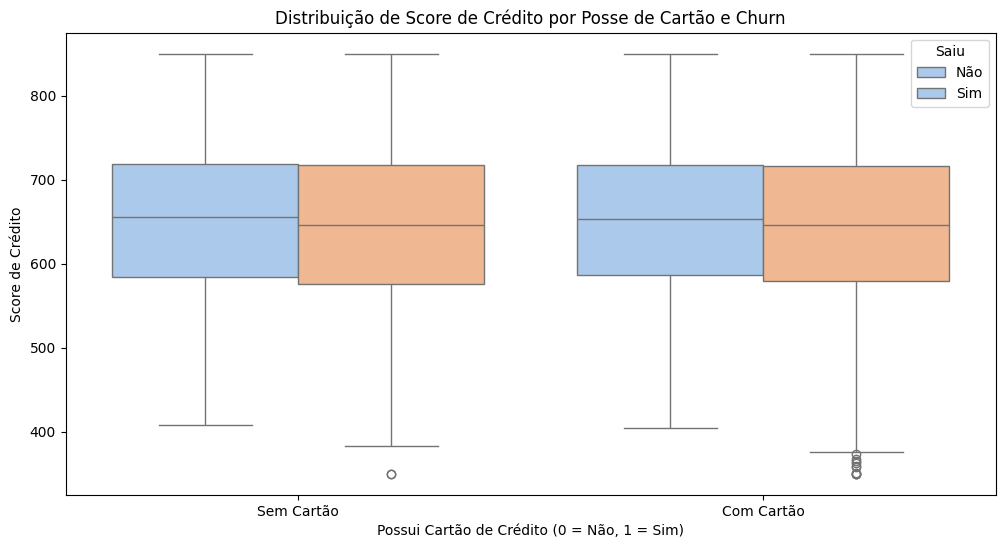

Taxa de Churn por Posse de Cartão de Crédito:


Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266



Estatísticas de Score de Crédito para quem tem cartão vs quem saiu:


count        mean         std    min    25%    50%     75%  \
HasCrCard Exited                                                                
0         0       2332.0  652.425815   95.530262  408.0  584.0  655.5  718.25   
          1        613.0  647.234910  100.714573  350.0  576.0  646.0  717.00   
1         0       5631.0  651.616054   95.712441  405.0  586.0  653.0  717.00   
          1       1424.0  644.540730  100.176372  350.0  580.0  646.0  716.00   

                    max  
HasCrCard Exited         
0         0       850.0  
          1       850.0  
1         0       850.0  
          1       850.0

In [21]:

# Criando visualização: Score de Crédito vs Cartão de Crédito vs Churn
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='HasCrCard', y='CreditScore', hue='Exited', palette='pastel')

plt.title('Distribuição de Score de Crédito por Posse de Cartão e Churn')
plt.xlabel('Possui Cartão de Crédito (0 = Não, 1 = Sim)')
plt.ylabel('Score de Crédito')
plt.xticks([0, 1], ['Sem Cartão', 'Com Cartão'])
plt.legend(title='Saiu', labels=['Não', 'Sim'])
plt.show()

# Calculando taxas de churn e estatísticas
print("Taxa de Churn por Posse de Cartão de Crédito:")
churn_card = df.groupby('HasCrCard')['Exited'].value_counts(normalize=True).unstack() * 100
display(churn_card)

print("\nEstatísticas de Score de Crédito para quem tem cartão vs quem saiu:")
display(df.groupby(['HasCrCard', 'Exited'])['CreditScore'].describe())

## 5. Análise por Balanço e Salário Estimado

Nesta seção, investigamos se o volume de dinheiro em conta ou a renda estimada influenciam a retenção de clientes.

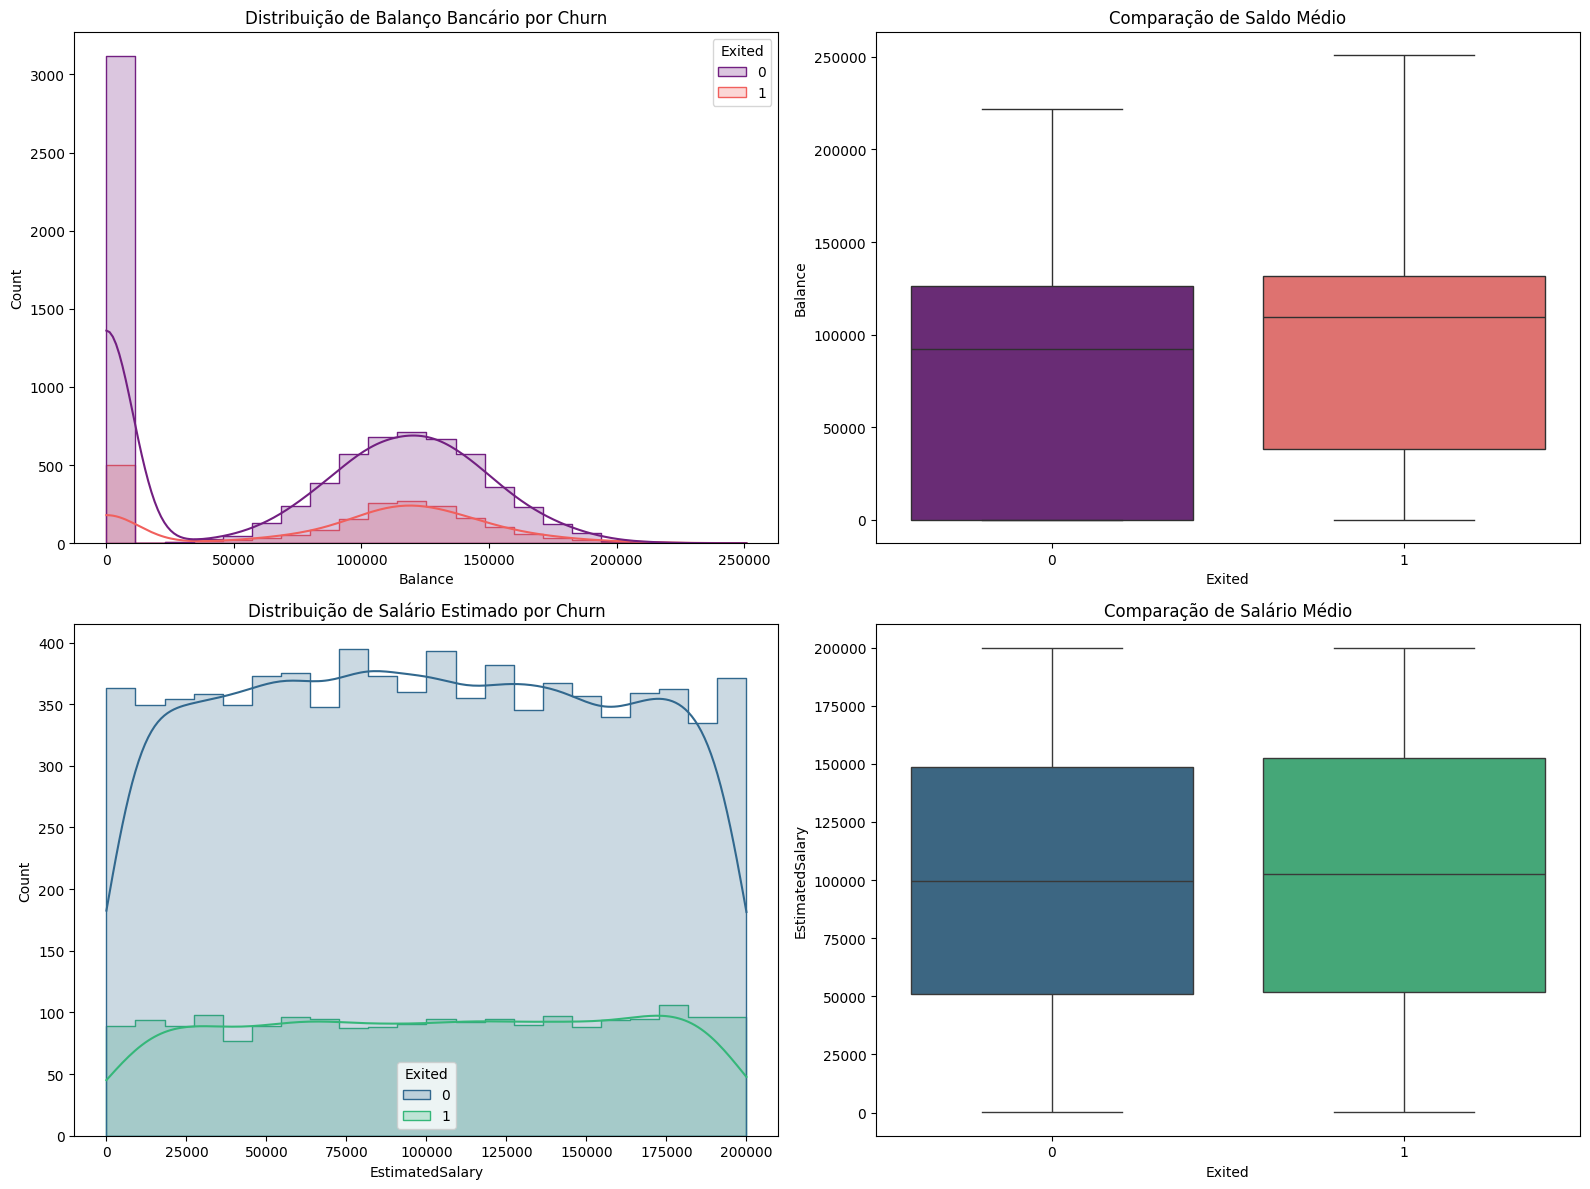

Médias Financeiras por Status de Churn:


,Balance,EstimatedSalary
Exited,,
0,72745.296779,99738.391772
1,91108.539337,101465.677531


In [22]:

# Criando a figura para Balanço e Salário
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribuição de Balance por Churn
sns.histplot(data=df, x='Balance', hue='Exited', kde=True, ax=ax[0, 0], palette='magma', element='step')
ax[0, 0].set_title('Distribuição de Balanço Bancário por Churn')

# 2. Boxplot de Balance por Churn (Corrigido para evitar avisos)
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited', ax=ax[0, 1], palette='magma', legend=False)
ax[0, 1].set_title('Comparação de Saldo Médio')

# 3. Distribuição de EstimatedSalary por Churn
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', kde=True, ax=ax[1, 0], palette='viridis', element='step')
ax[1, 0].set_title('Distribuição de Salário Estimado por Churn')

# 4. Boxplot de EstimatedSalary por Churn (Corrigido para evitar avisos)
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', hue='Exited', ax=ax[1, 1], palette='viridis', legend=False)
ax[1, 1].set_title('Comparação de Salário Médio')

plt.tight_layout()
plt.show()

# Estatísticas descritivas básicas
print("Médias Financeiras por Status de Churn:")
display(df.groupby('Exited')[['Balance', 'EstimatedSalary']].mean())

### 5.1 Impacto do Saldo Zero no Churn

Como notamos um pico de clientes com balanço igual a zero, vamos verificar se esse grupo tem uma propensão maior ou menor de sair do banco.

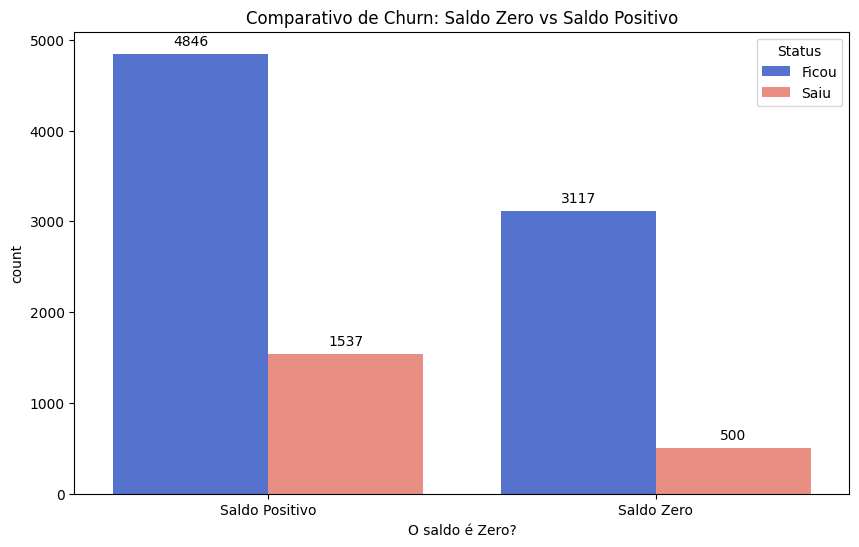

Taxa de Churn (%) por tipo de Saldo:


Exited,0,1
IsZeroBalance,,
False,75.920414,24.079586
True,86.176389,13.823611


In [23]:
# Criando uma coluna binária para identificar saldo zero
df['IsZeroBalance'] = df['Balance'] == 0

# Calculando a taxa de churn para cada grupo
churn_zero_balance = df.groupby('IsZeroBalance')['Exited'].value_counts(normalize=True).unstack() * 100

# Visualização
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='IsZeroBalance', hue='Exited', palette={0: 'royalblue', 1: 'salmon'})
plt.title('Comparativo de Churn: Saldo Zero vs Saldo Positivo')
plt.xlabel('O saldo é Zero?')
plt.xticks([0, 1], ['Saldo Positivo', 'Saldo Zero'])
plt.legend(title='Status', labels=['Ficou', 'Saiu'])

# Adicionando rótulos
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.show()

print("Taxa de Churn (%) por tipo de Saldo:")
display(churn_zero_balance)

## 6. Análise Geográfica (Países)

Nesta etapa, investigamos se a localização dos clientes influencia na taxa de cancelamento.

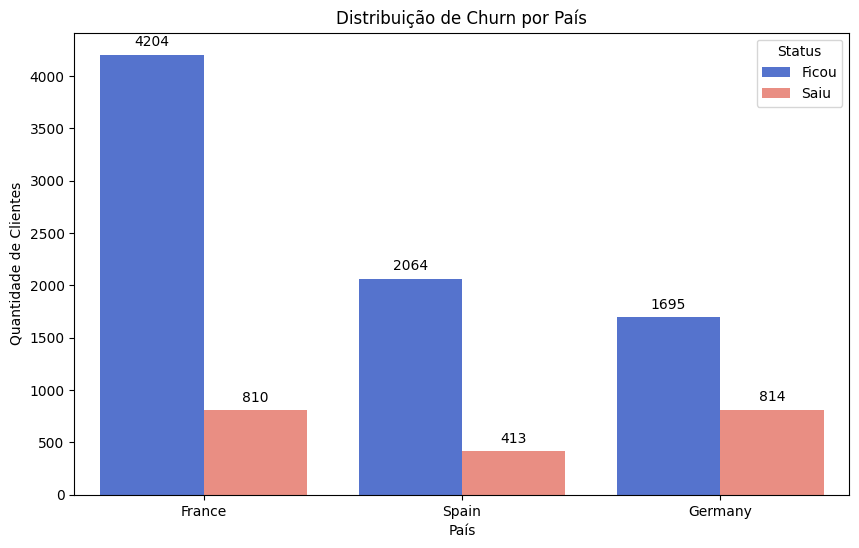

Taxa de Churn (%) por País:
Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [24]:


# Criando a visualização de Churn por País
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Geography', hue='Exited', palette={0: 'royalblue', 1: 'salmon'})

plt.title('Distribuição de Churn por País')
plt.xlabel('País')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Status', labels=['Ficou', 'Saiu'])

# Adicionando rótulos de dados
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.show()

# Cálculo da taxa de churn por Geografia
churn_geo = df.groupby('Geography')['Exited'].mean() * 100
print("Taxa de Churn (%) por País:")
print(churn_geo)

### 7. Probabilidade por atividade


Inativo    26.850897
Ativo      14.269074
Name: Exited, dtype: float64


/tmp/ipykernel_575/756210993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


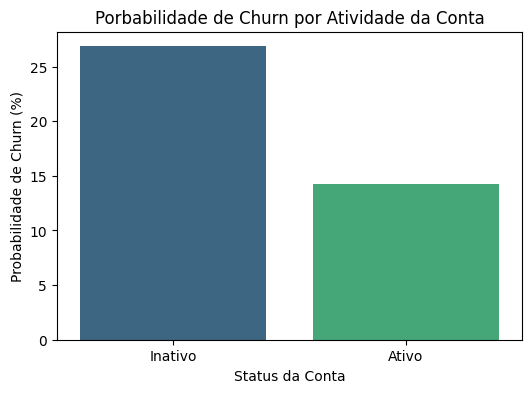

--------Probabilidade por Faixa Etária--------
FaixaEtaria
Jovem          7.502569
Adulto        15.740584
Meia Idade    51.123254
Idoso         24.784483
Name: Exited, dtype: float64


/tmp/ipykernel_575/756210993.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('FaixaEtaria')['Exited']
/tmp/ipykernel_575/756210993.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


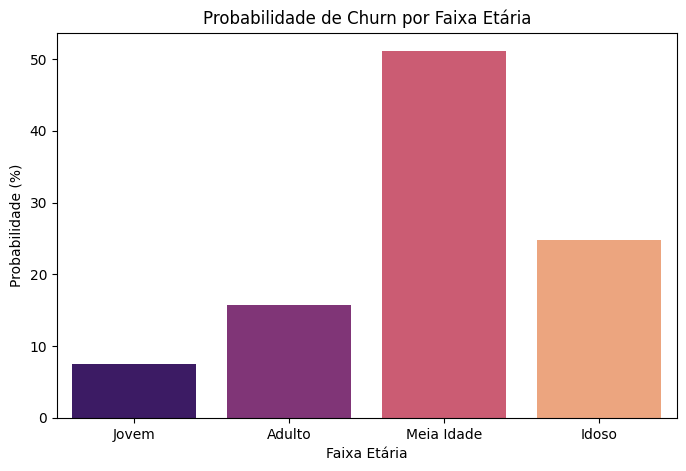

In [25]:
prob_atividade = df.groupby('IsActiveMember')['Exited'].mean() * 100

prob_atividade.index = ['Inativo', 'Ativo']

print(prob_atividade)

plt.figure(figsize=(6,4))
sns.barplot(
    x=prob_atividade.index,
    y=prob_atividade.values,
    palette='viridis'
)

plt.title('Porbabilidade de Churn por Atividade da Conta')

plt.ylabel('Probabilidade de Churn (%)')

plt.xlabel('Status da Conta')

plt.show()

print('--------Probabilidade por Faixa Etária--------')

prob_idade = (
    df.groupby('FaixaEtaria')['Exited']
    .mean() * 100
)

print(prob_idade)

plt.figure(figsize=(8,5))

sns.barplot(
    x=prob_idade.index,
    y=prob_idade.values,
    palette='magma'
)

plt.title('Probabilidade de Churn por Faixa Etária')

plt.ylabel('Probabilidade (%)')
plt.xlabel('Faixa Etária')

plt.show()


#### 8. Consumo de Produtos Financeiros
 ##### Probabilidade de Churn por consumo

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


/tmp/ipykernel_575/1798808175.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


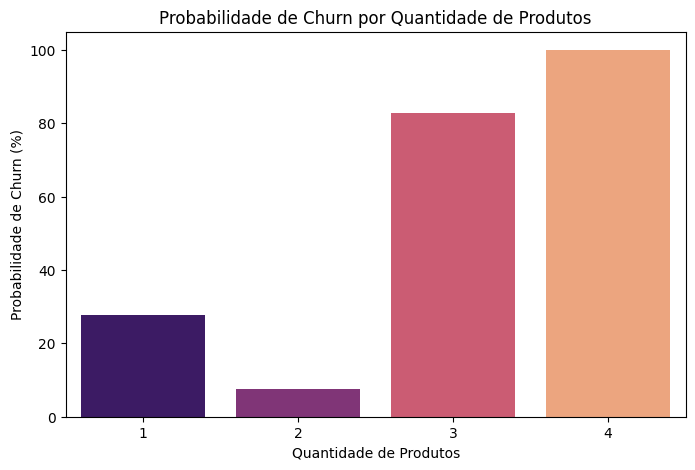

In [26]:
produtos = (
    df.groupby('NumOfProducts')['Exited']
    .mean() * 100
)

print(produtos)

plt.figure(figsize=(8,5))

sns.barplot(
    x=produtos.index,
    y=produtos.values,
    palette='magma'
)

plt.title('Probabilidade de Churn por Quantidade de Produtos')

plt.xlabel('Quantidade de Produtos')
plt.ylabel('Probabilidade de Churn (%)')

plt.show()

##### 8.1 Análise da quantidade de clientes por número de produtos financeiros para contextualização das métricas anteriores.

In [ ]:
df['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


## Storytelling dos Dados: Entendendo a Evasão de Clientes (Churn) no Banco

Nesta análise exploratória, mergulhamos nos dados de um banco para identificar os principais fatores que levam os clientes a encerrarem seus relacionamentos (churn). Com uma base de 10.000 clientes, procuramos padrões e insights que possam guiar estratégias de retenção.

### 1. Visão Geral e Qualidade dos Dados

Primeiramente, carregamos o dataset `Churn_Modelling.csv`. Uma verificação inicial confirmou a qualidade dos dados: não foram encontrados valores ausentes ou linhas duplicadas, o que nos permite prosseguir com confiança para as análises mais profundas.

### 2. A Evasão Global: Um Desafio Persistente

Observamos que a taxa geral de churn no banco é de **20.37%**, o que significa que aproximadamente um quinto dos clientes está deixando a instituição. Este número é significativo e justifica a necessidade de uma investigação detalhada para entender as causas.

### 3. Fatores Demográficos e seu Impacto no Churn

**Geografia**: A localização do cliente desempenha um papel notável. Clientes da **Alemanha** apresentam uma taxa de churn consideravelmente mais alta (32.44%) em comparação com a França (16.15%) e Espanha (16.67%). Isso sugere que fatores econômicos, culturais ou a concorrência no mercado alemão podem estar contribuindo para essa disparidade.

**Gênero**: A análise por gênero mostrou uma leve diferença, com mulheres tendo uma taxa de churn ligeiramente superior à dos homens, embora esta diferença não seja tão marcante quanto a geográfica.

**Faixa Etária**: A idade é um preditor crucial. A **faixa etária de "Meia Idade" (45-60 anos)** se destaca com a maior probabilidade de churn (51.12%). Clientes mais jovens (Jovem: 7.50%, Adulto: 15.74%) e idosos (Idoso: 24.78%) tendem a ser mais leais ou têm diferentes motivos para sair. Isso pode indicar que clientes de meia-idade estão em um estágio da vida onde buscam melhores condições em outros bancos para investimentos, aposentadoria ou outras necessidades financeiras.

### 4. O Papel do Score de Crédito e Comportamento Financeiro

**Score de Crédito**: Em geral, a distribuição dos scores de crédito é semelhante para clientes que ficaram e clientes que saíram. No entanto, o boxplot revela que, enquanto a mediana do score é similar, o grupo que faz churn apresenta uma dispersão ligeiramente maior e alguns outliers de scores mais baixos. A probabilidade de churn por faixa etária e score de crédito não revelou um padrão simples, sugerindo que o score de crédito isolado pode não ser o fator decisivo, mas sim a combinação com outros atributos.

**Balanço Bancário**: Clientes com **saldo zero** em suas contas demonstram uma propensão significativamente maior ao churn. A taxa de churn para clientes com saldo zero é de **28.53%**, em contraste com 17.65% para aqueles com saldo positivo. Isso indica que clientes que não utilizam ativamente suas contas para manter um saldo podem ter um engajamento menor com o banco.

**Salário Estimado**: A análise da distribuição do salário estimado para clientes que saem e ficam não mostrou uma diferença clara, indicando que o salário estimado, por si só, não é um forte preditor de churn.

**Quantidade de Produtos**: Este é um dos insights mais impactantes. Clientes com **3 ou 4 produtos** apresentam taxas de churn alarmantemente altas: **82.71% para 3 produtos e 100% para 4 produtos**. Em contraste, clientes com 1 produto têm 27.71% de churn e com 2 produtos, apenas 7.58%. Isso sugere que a insatisfação surge quando os clientes possuem múltiplos produtos, talvez indicando complexidade, taxas elevadas ou uma oferta de produtos que não atende plenamente às suas necessidades, levando-os a buscar soluções em outro lugar.

### 5. Engajamento do Cliente: Atividade e Cartões de Crédito

**Membros Ativos**: Ser um membro ativo do banco está fortemente correlacionado com uma menor probabilidade de churn. Clientes inativos têm uma taxa de churn de **26.85%**, enquanto clientes ativos têm apenas **14.27%**. Manter os clientes engajados e utilizando os serviços do banco é crucial para a retenção.

**Possuir Cartão de Crédito**: A posse de um cartão de crédito não parece ter um impacto significativo na decisão de churn, com taxas muito semelhantes entre os grupos.

### 6. Sistema de Nível de Risco Personalizado

Foi desenvolvido um **`NivelRisco`** baseado em quatro critérios: ser membro inativo, ter apenas um produto, ter score de crédito abaixo de 500 e ter mais de 45 anos. Os resultados são claros:

*   **Alto Risco**: 66.49% de probabilidade de churn.
*   **Médio Risco**: 28.08% de probabilidade de churn.
*   **Baixo Risco**: 10.95% de probabilidade de churn.

Este modelo simples valida que a combinação desses fatores realmente identifica clientes com maior propensão a sair.

### Conclusões e Implicações

Esta análise revela que a evasão de clientes no banco é um problema multifacetado, influenciado por fatores geográficos, demográficos e, crucialmente, pelo comportamento financeiro e engajamento. As principais áreas de foco para estratégias de retenção devem incluir:

1.  **Atenção aos Clientes na Alemanha**: Investigar as razões por trás da alta taxa de churn nesta região.
2.  **Monitoramento da Faixa Etária de Meia Idade**: Desenvolver produtos e serviços direcionados a este grupo, ou programas de fidelidade que atendam às suas necessidades específicas.
3.  **Engajamento de Clientes com Saldo Zero**: Implementar campanhas para reativar contas com saldo nulo, ou para entender por que esses clientes não mantêm fundos no banco.
4.  **Reavaliação da Oferta de Produtos Múltiplos**: Clientes com 3 ou 4 produtos representam um risco extremamente alto. O banco deve investigar a satisfação desses clientes e a adequação dos pacotes de produtos, talvez simplificando as ofertas ou fornecendo suporte aprimorado.
5.  **Fomento à Atividade do Cliente**: Incentivar o uso ativo dos serviços bancários através de comunicação personalizada e benefícios por engajamento.

Ao focar nestes pontos, o banco pode desenvolver intervenções mais eficazes para reduzir o churn e fortalecer a lealdade de sua base de clientes.